# 2. Preprocessing, features and training

From raw EDF files to the submitted model (`model/weights/model.json`, protocol 8): the pipeline, the features and what they mean, leakage-free validation, training, the comparison with and without behaviour, and the history of protocols 1 to 8.

The submitted model uses resting EEG only. Inference and metrics are in notebook 3, confounders in notebook 4.

In [1]:
import json
import sys
import tempfile
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from model.model import load, save, train
from src import config, dataset, evaluation, features, final_model, models, preprocessing, task_branch, viz

warnings.filterwarnings("ignore", message="The least populated class")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation"
P8 = models.PROTOCOL_8

## 2.1 Pipeline

| Step | What is done | Why |
| --- | --- | --- |
| Reading | six channels by name, samples converted to µV | channel order differs between files |
| Edges | the zero tail of format B is trimmed | the step from signal to zero follows the label |
| Sampling rate | resampling to 125 Hz | the data contain 123 to 127 Hz |
| Low-pass filter | 40 Hz | above 40 Hz the spectrum depends on the format |
| Windows | 4 s with a 2 s step | 0.25 Hz resolution without joining separate segments |
| Rejection | flat signal, clipping, range above 400 µV, outlying variance, dropout, copied channel | same thresholds for everyone; ICA without EOG is unreliable on six channels |
| Spectrum | mean of log periodograms with a bias correction | the estimate does not depend on the number of retained windows |
| Features | relative power, alpha peak, slope, asymmetry | independent of overall channel gain |
| Model | imputation, standardisation, L2 logistic regression, Platt calibration | with 25 patients the model has to be simple and interpretable |

No separate signal normalisation is needed because the features are relative and standardisation happens inside the model. We do not re-reference: an average reference over six leads is unreliable.

## 2.2 Rejection on single recordings

Window start on the horizontal axis, channel on the vertical axis, colour shows the reason for rejection. Top: rest of a PTSD patient. Bottom: a trial of a somatoform patient with artefacts on the temporal channels.

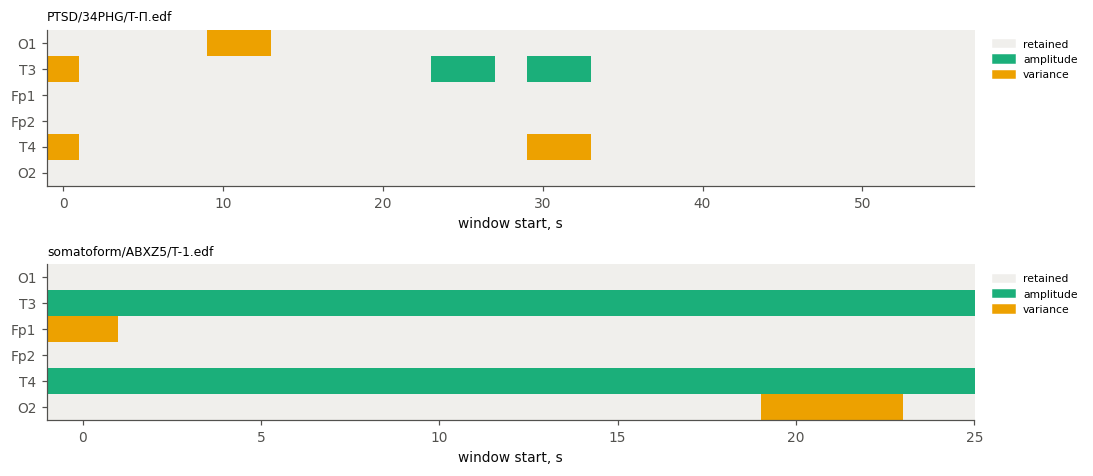

share of retained windows,O1,T3,Fp1,Fp2,T4,O2
PTSD/34PHG/T-П.edf,0.931,0.828,1.000,1.0,0.897,1.000
somatoform/ABXZ5/T-1.edf,1.000,0.000,0.923,1.0,0.000,0.846


In [2]:
examples = [config.GROUP_PTSD + "/34PHG/T-П.edf", config.GROUP_SOMATOFORM + "/ABXZ5/T-1.edf"]
cfg = preprocessing.PreprocessingConfig()
fig, axes = plt.subplots(len(examples), 1, figsize=(10, 4.4))
rows = []
for ax, relpath in zip(axes, examples):
    epoched = preprocessing.preprocess_file(config.DATA_DIR / relpath, cfg)
    viz.plot_rejection(ax, epoched.reject, cfg.step_s)
    ax.set_title(viz.english(relpath), loc="left", fontsize=8)
    rows.append(pd.Series(epoched.good.mean(axis=0), index=config.CHANNELS, name=viz.english(relpath)))
plt.tight_layout()
plt.show()
pd.DataFrame(rows).rename_axis(columns="share of retained windows")

Recording quality depends on the cohort: patients lose more windows than controls. It is therefore not given to the model. A model trained on quality alone is tested in notebook 4.

## 2.3 Spectrum and features of one subject

Rest, O1, a format A control. The 1/f background is a straight line in log–log coordinates fitted on 3–30 Hz without 7–14 Hz; its slope χ is `rest_exponent`. The alpha peak is measured above this background (`rest_iaf_O1`, `rest_alpha_peak_O1`), together with the band powers.

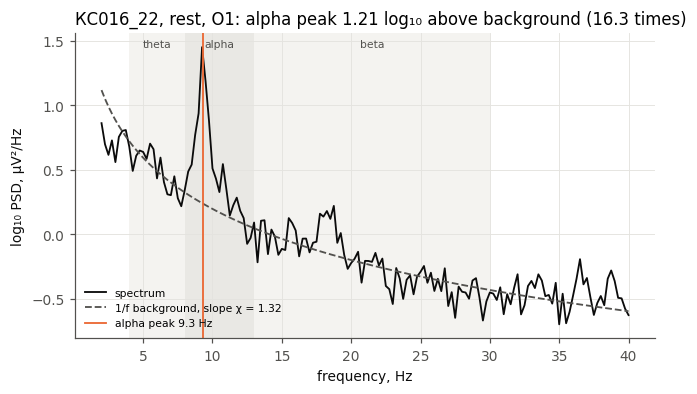

,rest_relpow_theta_O1,rest_relpow_theta_Fp1,rest_relpow_theta_Fp2,rest_relpow_theta_T3,rest_relpow_theta_T4,rest_relpow_alpha_O1,rest_relpow_alpha_Fp1,rest_relpow_alpha_Fp2,rest_relpow_alpha_T3,rest_relpow_alpha_T4,...,rest_relpow_beta_T3,rest_relpow_beta_T4,rest_iaf_O1,rest_alpha_peak_O1,rest_exponent_O1,rest_exponent_Fp1,rest_exponent_Fp2,rest_exponent_T3,rest_exponent_T4,rest_faa
КС016_22,-0.566,-0.689,-0.637,-0.446,-0.63,-0.306,-0.174,-0.203,-0.506,-0.298,...,-0.482,-0.582,9.304,1.211,1.319,1.371,1.386,1.201,1.117,0.1


In [3]:
example = config.DATA_DIR / config.GROUP_CONTROL / "КС016_22"
files = dataset.find_record_files(example)
epoched = preprocessing.preprocess_file(files[config.REST_STEM], cfg)
freqs, spectrum = features.record_spectrum(epoched)
log_o1 = np.log10(spectrum[config.CHANNELS.index("O1")])
chi, offset = features.background_fit(freqs, log_o1)
iaf, peak = features.alpha_peak(freqs, log_o1)
fig, ax = plt.subplots(figsize=(6.8, 3.6))
viz.plot_spectrum_features(ax, freqs, log_o1, chi, offset, iaf)
ax.set_title(f"{example.name}, rest, O1: alpha peak {peak:.2f} log₁₀ above background ({10 ** peak:.1f} times)", loc="left")
plt.show()

subject = features.extract_subject_features(files)
model_features = P8.feature_sets["rest_O1FpT_exp"][1]
pd.Series({name: subject[name] for name in model_features}, name=example.name).to_frame().T

## 2.4 Features of the submitted model

23 features of rest with eyes closed:

| Feature | Leads | Meaning |
| --- | --- | --- |
| relative power of theta 4–8, alpha 8–13 and beta 13–30 Hz (15) | O1, Fp1, Fp2, T3, T4 | balance of resting rhythms; faster and weaker alpha and a flatter spectrum are reported in PTSD (Kovacevic et al., 2025) |
| alpha peak frequency | O1 | speed of the alpha rhythm, slows with age |
| alpha peak height | O1 | strength of the eyes-closed alpha |
| spectral slope (5) | O1, Fp1, Fp2, T3, T4 | aperiodic background (Donoghue et al., 2020), flatter in PTSD and with age |
| frontal alpha asymmetry | Fp1, Fp2 | approach and avoidance model; Fp leads are sensitive to eye movements |

O2 is not used because in the supplementary batch it behaves like a frontal channel. T3 and T4 are kept, and their influence is tested in notebook 4. Connectivity and microstates are not used (notebook 1, section 1.10).

In [4]:
data = models.load_training_data(protocol=P8)
x = pd.DataFrame(data.tables["rest_O1FpT_exp"], index=list(data.subject_keys), columns=data.feature_names["rest_O1FpT_exp"])
print(f"Subjects: {len(data.subject_keys)}, independent groups: {np.unique(data.groups).size}, features: {x.shape[1]}")
missing = x.isna().groupby(data.stratum).mean()
pd.DataFrame({
    "subjects": pd.Series(data.stratum).value_counts(),
    "missing O1/Fp": missing[[c for c in x.columns if c.endswith(("_O1", "_Fp1", "_Fp2"))]].mean(axis=1),
    "missing T3/T4": missing[[c for c in x.columns if c.endswith(("_T3", "_T4"))]].mean(axis=1),
    "no alpha peak": missing["rest_iaf_O1"],
    "missing FAA": missing["rest_faa"],
}).reindex(list(viz.STRATUM_ORDER)).rename(index=viz.STRATUM_LABELS)

Subjects: 229, independent groups: 221, features: 23


,subjects,missing O1/Fp,missing T3/T4,no alpha peak,missing FAA
PTSD,25,0.020,0.020,0.080,0.000
control A,20,0.014,0.000,0.200,0.000
control B,2,0.000,0.000,0.000,0.000
control C,45,0.071,0.000,1.000,0.000
suppl. controls,40,0.009,0.212,0.125,0.000
controls 65+,23,0.056,0.087,0.783,0.000
somatoform,74,0.054,0.216,0.203,0.027


A value is missing when a channel has fewer than five retained windows. Alpha peak frequency is also missing when there is no peak. Missing values are filled with the training median.

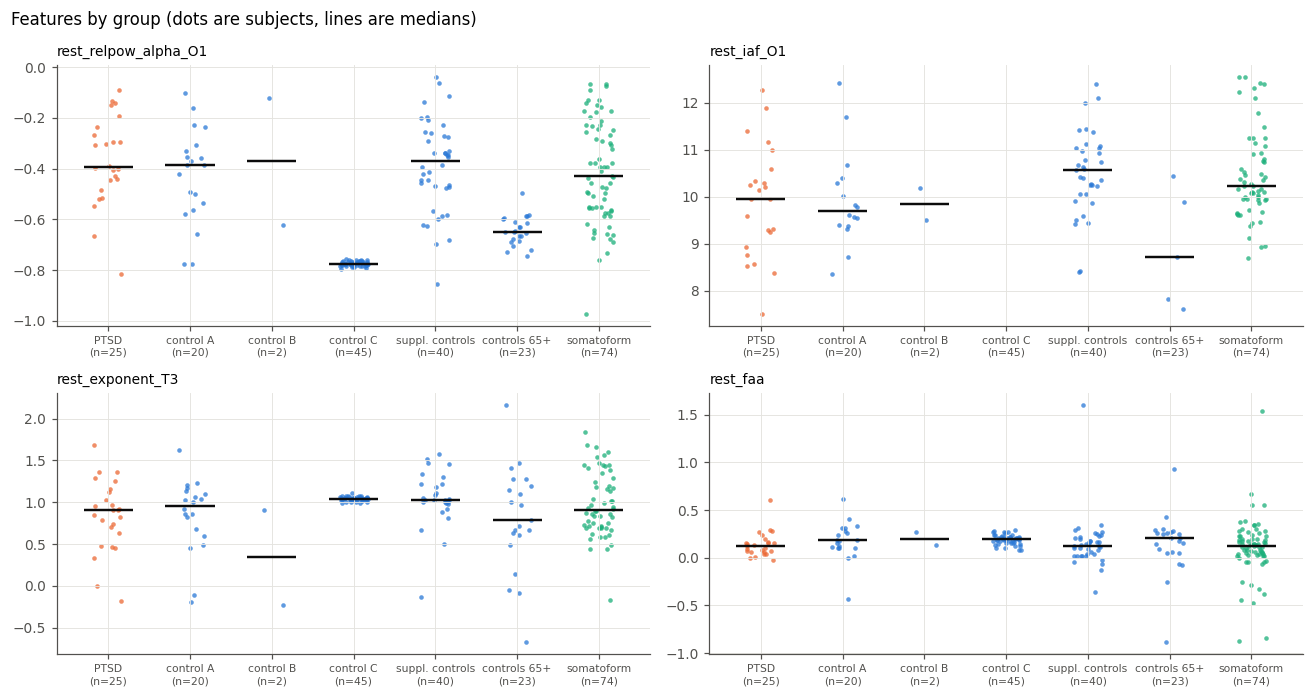

In [5]:
show = ["rest_relpow_alpha_O1", "rest_iaf_O1", "rest_exponent_T3", "rest_faa"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
for ax, name in zip(axes.ravel(), show):
    viz.plot_by_stratum(ax, x[name].to_numpy(), data.stratum)
    ax.set_title(name, loc="left", fontsize=9)
fig.suptitle("Features by group (dots are subjects, lines are medians)", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## 2.5 Validation without leakage

- The unit of every split is a duplicate group: IDs that share recordings always stay together.
- The outer loop is leave-one-group-out, stricter than the leave-one-subject-out required by the task.
- The inner loop is a group 5-fold cross-validation that chooses the features, C, the negative class and the calibration.
- Imputation, standardisation, weights and calibration are fitted on the training part only, and no windows are shared between training and test.

In [6]:
folds = evaluation.outer_folds(data.groups)
keys = np.array(data.subject_keys)
assert all(np.intersect1d(data.groups[tr], data.groups[te]).size == 0 for tr, te in folds)
assert all(np.intersect1d(keys[tr], keys[te]).size == 0 for tr, te in folds)
multi = pd.Series(keys).groupby(data.groups).agg(list)
print(f"Outer folds: {len(folds)}; subjects: {keys.size}; groups shared between train and test: 0")
print("Groups with several IDs (shared recordings):")
multi[multi.str.len() > 1].map(lambda ks: [viz.english(k) for k in ks]).to_frame("IDs in group")

Outer folds: 221; subjects: 229; groups shared between train and test: 0
Groups with several IDs (shared recordings):


,IDs in group
132,"[PTSD/DFGH, PTSD/WSXD]"
163,"[somatoform/DIKL0, somatoform/GHRD3]"
179,"[somatoform/KRTM8, somatoform/PYVB0]"
181,"[somatoform/LDPR3, somatoform/ZILO6]"
187,"[somatoform/MVCP4, somatoform/ORSU8]"
193,"[somatoform/QJHD2, somatoform/YLKT9]"
200,"[somatoform/RZFM9, somatoform/VGYN1]"
202,"[somatoform/SIGO3, somatoform/TMVN4]"


## 2.6 Candidates and selection criterion

There are 80 candidates: four feature sets, five values of C, two choices of the negative class and two weights for controls aged 65+ and somatoform patients. The criterion mirrors the official score without its threshold part:

`30·max(0, (AUC_controls − 0.5)/0.5) + 20·max(0, (AUC_specificity − 0.5)/0.5)`,

where AUC_controls is PTSD against controls under 65 and AUC_specificity is PTSD against controls aged 65+ and somatoform patients. After Platt calibration the threshold is moved to the point where sensitivity on PTSD equals specificity on those two groups, using inner out-of-fold predictions.

In [7]:
sets = {key: len(names) for key, (_, names) in P8.feature_sets.items()}
print("Feature sets (number of features):", sets)
print("Candidates:", len(P8.candidates))

Feature sets (number of features): {'rest_O1Fp': 12, 'rest_O1Fp_exp': 15, 'rest_O1FpT': 18, 'rest_O1FpT_exp': 23}
Candidates: 80


## 2.7 Nested evaluation (protocol 8)

In each of the 221 outer folds the whole procedure is repeated: selection, training and calibration. The result is compared with the saved run.

In [8]:
oof = evaluation.nested_oof(data, P8)
committed = pd.read_csv(VALIDATION / "protocol8" / "nested_oof.csv", index_col=0).loc[oof.index]
print(f"Largest difference from the saved run: {np.abs(oof['p'] - committed['p']).max():.1e}")
print("Selected candidates across outer folds:", evaluation.candidate_frequency(oof))
per_fold = oof.groupby("split_group")[["cal_a", "cal_b"]].first()
print(f"Platt calibration across folds: a median {per_fold['cal_a'].median():.2f} "
      f"[{per_fold['cal_a'].min():.2f}; {per_fold['cal_a'].max():.2f}], b median {per_fold['cal_b'].median():.2f}")
report = evaluation.summarize_protocol3(oof, data.groups)
pd.DataFrame({
    col: {
        "AUC PTSD / controls < 65": report[col]["auc_ptsd_vs_controls_excl_ageing"]["value"],
        "AUC PTSD / controls A, B, suppl.": report[col]["auc_ptsd_vs_controls_AB"]["value"],
        "AUC PTSD / controls 65+": report[col]["auc_ptsd_vs_stratum"]["control_ageing"],
        "AUC PTSD / somatoform": report[col]["auc_ptsd_vs_stratum"]["somatoform"],
        "sensitivity at 0.5": report[col]["threshold_metrics"]["sensitivity_ptsd"],
        "specificity 65+": report[col]["specificity_ageing"]["value"],
        "specificity somatoform": report[col]["specificity_somatoform"]["value"],
    }
    for col in ("p_raw", "p")
}).rename(columns={"p_raw": "uncalibrated", "p": "calibrated (submitted)"})

Largest difference from the saved run: 1.1e-16
Selected candidates across outer folds: {'C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp': 136, 'C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp|w=3': 55, 'C=1.0|neg=control|feat=rest_O1FpT_exp|w=3': 12, 'C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp|w=3': 10, 'C=1.0|neg=control|feat=rest_O1FpT_exp': 8}
Platt calibration across folds: a median 0.69 [0.31; 0.88], b median 0.27


,uncalibrated,calibrated (submitted)
AUC PTSD / controls < 65,0.864,0.824
"AUC PTSD / controls A, B, suppl.",0.765,0.697
AUC PTSD / controls 65+,0.890,0.877
AUC PTSD / somatoform,0.792,0.731
sensitivity at 0.5,0.800,0.840
specificity 65+,0.870,0.870
specificity somatoform,0.662,0.608


The calibrated out-of-fold AUC is lower because each fold has its own calibration. The final model has a single calibration, which does not change the ranking. Metrics with confidence intervals are in notebook 3.

## 2.8 Final model

The same procedure is run on all 229 subjects. Weights are stored as plain arrays in JSON, without pickle. Retraining reproduces them up to rounding.

In [9]:
fitted = train()
committed_model = load(ROOT / "model" / "weights")
with tempfile.TemporaryDirectory() as tmp:
    save(fitted, Path(tmp))
    fitted_json = load(Path(tmp))
assert fitted_json.feature_names == committed_model.feature_names
max_param = max(np.max(np.abs(np.append(getattr(fitted_json, name), 0) - np.append(getattr(committed_model, name), 0)))
                for name in ("impute_values", "mean", "scale", "coef", "intercept", "calibration"))
x_all = data.tables[fitted.metadata["feature_set"]]
max_p = np.max(np.abs(fitted_json.predict_proba(x_all) - committed_model.predict_proba(x_all)))
print(f"Retraining against model/weights/model.json: max |Δ parameter| = {max_param:.1e}, max |Δ P| = {max_p:.1e}")
meta = fitted.metadata
print(f"Selected: {meta['candidate']}; trained on {meta['n_subjects_trained']} subjects ({meta['n_ptsd']} PTSD); "
      f"Platt calibration a = {fitted.calibration[0]:.3f}, b = {fitted.calibration[1]:.3f}")
top = pd.Series(meta["selection_scores"]).sort_values(ascending=False).head(5)
top.rename("inner CV criterion (out of 50)").to_frame()

Retraining against model/weights/model.json: max |Δ parameter| = 0.0e+00, max |Δ P| = 0.0e+00
Selected: C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp; trained on 229 subjects (25 PTSD); Platt calibration a = 0.822, b = 0.236


,inner CV criterion (out of 50)
C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp,30.858
C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp|w=3,30.209
C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp|w=3,30.103
C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp,30.031
C=1.0|neg=control|feat=rest_O1FpT_exp,28.657


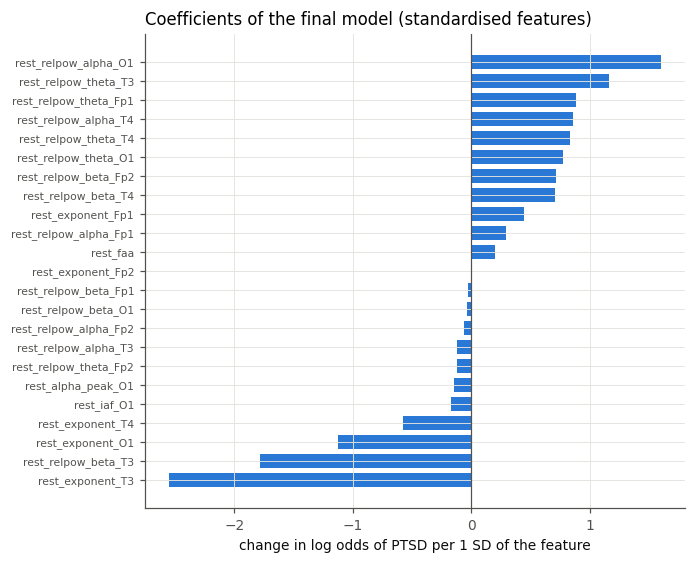

In [10]:
coef = pd.Series(fitted.coef, index=fitted.feature_names).sort_values()
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.barh(coef.index, coef.to_numpy(), color=viz.COHORT_COLORS[config.GROUP_CONTROL], height=0.7)
ax.axvline(0, color=viz.TEXT_MUTED, lw=0.8)
ax.set_xlabel("change in log odds of PTSD per 1 SD of the feature")
ax.set_title("Coefficients of the final model (standardised features)", loc="left")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

A positive coefficient means that a larger feature value raises P. The features are correlated, so the coefficients show direction rather than independent effects. Interpretation is in notebook 4, section 4.7.

## 2.9 With and without behaviour

Behaviour here is the solve time of the first Schulte table. Not everyone has it (format C lengths are templated and the supplementary batch has no trials), so the comparison uses 142 subjects: PTSD, controls A and B, controls 65+ and somatoform patients. Three models are trained on the same people and splits: behaviour only, EEG only (the features of the submitted model) and both.

In [11]:
table, subjects_t, stratum_t, family_t = final_model.build_tables()
population = final_model.training_population(table, subjects_t, stratum_t, family_t)
eeg_features = fitted.feature_names
specs = {"behaviour": final_model.BEHAVIOUR, "rest_eeg": eeg_features, "combined": final_model.BEHAVIOUR + eeg_features}
beh_oofs = {name: task_branch.nested_oof_task(population, feats, score=final_model.criterion) for name, feats in specs.items()}
beh_report = final_model.summarize(population, beh_oofs)
print("Subjects by group:", beh_report["n_by_stratum"])


def row(entry: dict) -> dict:
    e = entry["p_raw"]
    return {
        "AUC PTSD / controls A, B": e["auc_ptsd_vs_controls_AB"]["value"],
        "AUC PTSD / 65+ and somatoform": e["auc_ptsd_vs_ageing_and_somatoform"]["value"],
        "AUC PTSD / all non-PTSD": e["auc_ptsd_vs_all_non_ptsd"]["value"],
        "95% CI (all non-PTSD)": f"[{e['auc_ptsd_vs_all_non_ptsd']['ci_low']:.2f}; {e['auc_ptsd_vs_all_non_ptsd']['ci_high']:.2f}]",
        "AUC PTSD / controls 65+": e["auc_ptsd_vs_stratum"]["control_ageing"],
        "AUC PTSD / somatoform": e["auc_ptsd_vs_stratum"]["somatoform"],
    }


names = {"behaviour": "behaviour only", "rest_eeg": "EEG only", "combined": "EEG + behaviour"}
pd.DataFrame({names[k]: row(beh_report[k]) for k in names}).T

Subjects by group: {np.str_('control_A'): 20, np.str_('control_B'): 2, np.str_('control_ageing'): 23, np.str_('ptsd'): 25, np.str_('somatoform'): 72}


,"AUC PTSD / controls A, B",AUC PTSD / 65+ and somatoform,AUC PTSD / all non-PTSD,95% CI (all non-PTSD),AUC PTSD / controls 65+,AUC PTSD / somatoform
behaviour only,0.722,0.587,0.612,[0.50; 0.73],0.082,0.748
EEG only,0.498,0.677,0.644,[0.54; 0.74],0.833,0.628
EEG + behaviour,0.66,0.768,0.747,[0.65; 0.84],0.746,0.774


In [12]:
diffs = {
    "EEG + behaviour minus behaviour only": beh_report["combined_minus_behaviour_auc_all"],
    "EEG + behaviour minus EEG only": beh_report["combined_minus_rest_eeg_auc_all"],
}
pd.DataFrame(diffs).T.rename(columns={"value": "AUC difference (all non-PTSD)", "ci_low": "2.5%", "ci_high": "97.5%"})

,AUC difference (all non-PTSD),2.5%,97.5%
EEG + behaviour minus behaviour only,0.135,0.004,0.260
EEG + behaviour minus EEG only,0.104,0.034,0.176


Pre-registered comparisons from protocols 4 and 5 (AUC of PTSD against all non-PTSD subjects):

In [13]:
p4 = json.loads((VALIDATION / "protocol4" / "metrics.json").read_text(encoding="utf-8"))
p5 = json.loads((VALIDATION / "protocol5" / "metrics.json").read_text(encoding="utf-8"))
kinds = [("behaviour", "behaviour"), ("EEG", "eeg"), ("both", "combined")]
prereg = {
    f"protocol 4: first trial, task EEG ({sum(p4['trial1']['n_by_stratum'].values())})":
        {m: p4["trial1"][k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in kinds},
    f"protocol 4: dynamics over five trials ({sum(p4['dynamics']['n_by_stratum'].values())})":
        {m: p4["dynamics"][k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in kinds},
    f"protocol 5: first trial + rest EEG 4–20 Hz ({sum(p5['n_by_stratum'].values())})":
        {m: p5[k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in [("behaviour", "behaviour"), ("EEG", "rest_eeg"), ("both", "combined")]},
}
pd.DataFrame(prereg).T

,behaviour,EEG,both
"protocol 4: first trial, task EEG (142)",0.613,0.562,0.625
protocol 4: dynamics over five trials (115),0.759,0.531,0.729
protocol 5: first trial + rest EEG 4–20 Hz (142),0.612,0.573,0.656


Behaviour separates PTSD from young controls but mistakes older adults for PTSD, because they solve the tables more slowly. EEG does the opposite: it separates older adults but not controls A and B in this subset. Together they work better than either alone.

The submitted model uses EEG only. The task is EEG diagnostics, and 85 of the 229 training subjects have no behavioural data.

## 2.10 History of protocols 1 to 8

Every protocol was fixed before it was run, and failed ones are shown too. The data changed between protocols, so AUC values in different rows should be compared with care.

In [14]:
def load_metrics(name: str) -> dict:
    return json.loads((VALIDATION / name / "metrics.json").read_text(encoding="utf-8"))


m1, m2 = load_metrics("protocol1_corrected"), load_metrics("protocol2")
history = {
    "1: rest + task, 39 features, all channels": {
        "subjects": m1["n_subjects"], "AUC PTSD / controls": m1["auc_ptsd_vs_control"]["value"],
        "sensitivity": m1["sensitivity"], "specificity somatoform": m1["specificity_somatoform"]["value"],
        "specificity 65+": np.nan},
    "2: rest, no O2, ± T3/T4, slope, suppl. batch": {
        "subjects": sum(m2["n_by_stratum"].values()), "AUC PTSD / controls": m2["auc_ptsd_vs_all_controls"]["value"],
        "sensitivity": m2["sensitivity_ptsd"], "specificity somatoform": m2["specificity_somatoform"]["value"],
        "specificity 65+": np.nan},
}
for name, label in [("protocol3", "3: rest 4–20 Hz, O1/Fp, prevalence calibration"),
                    ("protocol6", "6: as 2 + controls 65+ in training, official criterion"),
                    ("protocol7", "7: as 6 + FAA, balanced calibration"),
                    ("protocol8", "8: as 7 + specificity weights, equal-error threshold (submitted)")]:
    m = load_metrics(name)
    history[label] = {
        "subjects": sum(m["n_by_stratum"].values()), "AUC PTSD / controls": m["p_raw"]["auc_ptsd_vs_controls_excl_ageing"]["value"],
        "sensitivity": m["p"]["threshold_metrics"]["sensitivity_ptsd"],
        "specificity somatoform": m["p"]["specificity_somatoform"]["value"],
        "specificity 65+": m["p"]["specificity_ageing"]["value"]}
pd.DataFrame(history).T

,subjects,AUC PTSD / controls,sensitivity,specificity somatoform,specificity 65+
"1: rest + task, 39 features, all channels",166.0,0.818,0.64,0.662,NaN
"2: rest, no O2, ± T3/T4, slope, suppl. batch",206.0,0.824,0.68,0.676,NaN
"3: rest 4–20 Hz, O1/Fp, prevalence calibration",229.0,0.659,0.00,1.000,1.000
"6: as 2 + controls 65+ in training, official criterion",229.0,0.848,0.00,0.986,1.000
"7: as 6 + FAA, balanced calibration",229.0,0.838,0.80,0.581,0.783
"8: as 7 + specificity weights, equal-error threshold (submitted)",229.0,0.864,0.84,0.608,0.870


- Protocols 1 and 2: the high AUC came almost entirely from format C and from batch differences through T3.
- Protocol 3: the most robust features (O1 and Fp, 4–20 Hz) did not separate PTSD from comparable controls, and calibrating to the training prevalence gave zero sensitivity.
- Protocols 4 and 5: the clearest signal was in behaviour (section 2.9).
- Protocols 6 and 7: EEG only, selection by the official formula, balanced calibration.
- Protocol 8, submitted: extra weight for the specificity groups and an equal-error threshold improved both AUC and specificity.

## 2.11 Summary

1. Preprocessing is the same in training and inference and never uses the label.
2. The model uses 23 rest features from five leads, all independent of channel gain.
3. Validation is leave-one-group-out over duplicate groups, with every choice made inside the fold. The same feature set was chosen in all 221 folds.
4. Out of sample, the model separates PTSD from controls under 65 with AUC 0.86 and detects most patients at the 0.5 threshold. Separation is weaker without format C.
5. Behaviour and EEG complement each other, but the submitted model uses EEG only.
6. The main risk is the reliance on T3/T4 and batch differences. Notebook 4 tests it.